 Fetch GitHub profile data
● Analyze repositories
● Compare followers and activity
● Visualize contribution trends
● Generate profile analytics
● Track programming language usage

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import requests 

username = input("Enter GitHub Username: ")

# -------------------------------
# User Profile
# -------------------------------
profile_url = f"https://api.github.com/users/{username}"

profile = requests.get(profile_url).json()

print("\n----- USER PROFILE -----")
print("Name :", profile.get("name"))
print("Username :", profile.get("login"))
print("Followers :", profile.get("followers"))
print("Following :", profile.get("following"))
print("Public Repositories :", profile.get("public_repos"))
print("Account Created :", profile.get("created_at"))

# -------------------------------
# Repositories
# -------------------------------
repo_url = f"https://api.github.com/users/{username}/repos"

repos = requests.get(repo_url).json()

repo_data = []

for repo in repos:
    repo_data.append({
        "Repository": repo["name"],
        "Stars": repo["stargazers_count"],
        "Forks": repo["forks_count"],
        "Language": repo["language"]
    })

df = pd.DataFrame(repo_data)

print("\nRepository Details")
print(df)

df.to_csv("GitHub_Repositories.csv", index=False)


----- USER PROFILE -----
Name : Bhesaniya drashti j
Username : bhesaniyadrashti
Followers : 0
Following : 0
Public Repositories : 6
Account Created : 2025-07-31T05:50:11Z

Repository Details
            Repository  Stars  Forks Language
0             Acedemix      1      0      PHP
1  codeveda_internship      0      0   Python
2  fake_news_detection      0      0     HTML
3  Food-Odering-system      1      0      CSS
4         my-portfolio      0      0      CSS
5  news-recommendation      0      0   Python


In [4]:
print("Total Repositories :", len(df))

print("Average Stars :", df["Stars"].mean())

print("Average Forks :", df["Forks"].mean())

Total Repositories : 6
Average Stars : 0.3333333333333333
Average Forks : 0.0


In [5]:
followers = profile["followers"]
following = profile["following"]

print("Followers :", followers)
print("Following :", following)

if followers > following:
    print("More Followers than Following")
else:
    print("Following More Users")

Followers : 0
Following : 0
Following More Users


In [6]:
language_count = df["Language"].value_counts()

print(language_count)

Language
Python    2
CSS       2
PHP       1
HTML      1
Name: count, dtype: int64


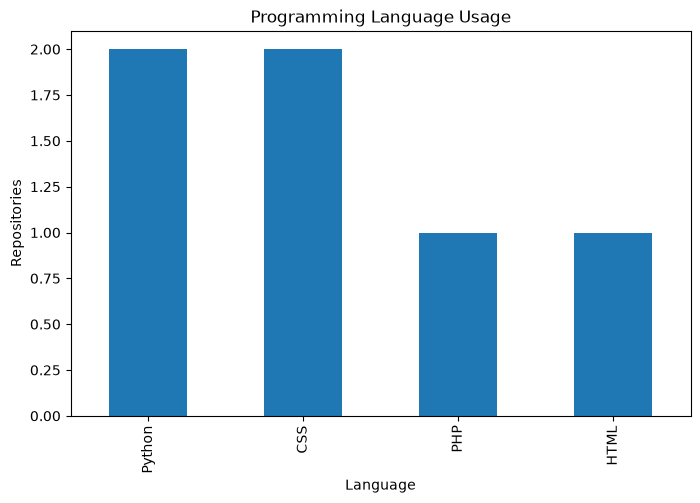

In [7]:
plt.figure(figsize=(8,5))

language_count.plot(kind="bar")

plt.title("Programming Language Usage")
plt.xlabel("Language")
plt.ylabel("Repositories")

plt.show()

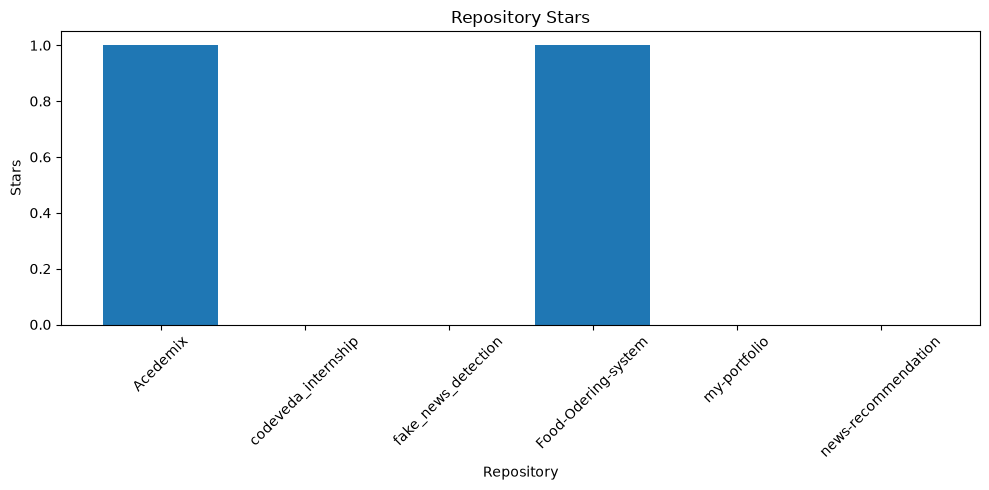

In [8]:
plt.figure(figsize=(10,5))

plt.bar(df["Repository"], df["Stars"])

plt.xticks(rotation=45)

plt.title("Repository Stars")
plt.xlabel("Repository")
plt.ylabel("Stars")

plt.tight_layout()
plt.show()

In [9]:
activity_url = f"https://api.github.com/users/{username}/events/public"

activity = requests.get(activity_url).json()

print("\nRecent Activity")

for event in activity[:10]:
    print(event["type"])


Recent Activity
PushEvent
CreateEvent


In [10]:
profile = requests.get(profile_url).json()
with open("GitHub_Profile_Report.txt", "w") as file:

    file.write("GitHub User Analytics\n\n")

    file.write(f"Username : {profile['login']}\n")
    file.write(f"Followers : {profile['followers']}\n")
    file.write(f"Following : {profile['following']}\n")
    file.write(f"Repositories : {profile['public_repos']}\n\n")

    file.write(df.to_string(index=False))

print("Report Saved Successfully")

Report Saved Successfully
